## DFT vs. MLIPs Energy Comparison Pipeline

This notebook compares 
$$E_{ads}^{MLIP} = E_{slab+ads}^{MLIP} - E_{slab}^{DFT} - \sum E_{refs}^{DFT} \\
\text{ and } \\ 
E_{ads}^{DFT} = E_{slab+ads}^{DFT} - E_{slab}^{DFT} - \sum E_{refs}^{DFT} $$
where refs are DFT potential energies of gas-phase reference molecules.

In [31]:
# TODO: write notebook description

# 12 plots instead of 4 (separate out models)
# try MAE by subtracting out different model/dft baselines and running MAE on that
# to consider: when doing E_adsorption, make sure E_total is on the same scale, or it might not work well?

#### 0. Configuration

In [82]:
from pathlib import Path
import numpy as np
from ase.io import iread, read, write

In [83]:
# builds a dict describing 1 DFT adsorbate run
# ads: single adsorbate string or two joined like ads1_ads2
# template: path template string with {ads}, {slab}, {config_id} placeholders;
#           define at call site (TEMPLATE in next cell) to handle
#           directory structure variants.

def make_run(ads, slab, config_id, template):
    run_id = f"{ads}_{slab}_{config_id}"
    return {
        "ads":       ads,
        "slab":      slab,
        "config_id": config_id,  # use arbitrary directory numbering to label ads config for now
        "run_id":    run_id,
        "path":      template.format(ads=ads, slab=slab, config_id=config_id),
    }

def make_model(name, python_bin, script_path):
    return {
        "name":       name,
        "python_bin": python_bin,
        "script":     script_path
    }

In [84]:
# USER INPUT HERE

# do you want to re-run model relaxations? (note: takes time!)
RUN_RELAXATIONS = False  # set to True when ready

# directory path template for adsorbate systems on YPdCu slab
YPDCU_TEMPLATE = "dft-data/YPdCu/{ads}_on_{slab}/{ads}_{slab}_{config_id}/vasprun.xml"

RUNS = (
    [make_run("CH3CHO",       "YO4PdCu", 3, YPDCU_TEMPLATE)] +
    [make_run("CO_CHO",       "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 15)] +
    [make_run("COCHO",        "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 19)] +
    [make_run("COOH",         "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 16)]
)

MODELS = [
    make_model("MACE",       "/Users/zschwab/miniconda3/envs/mlip-mace/bin/python",       "model-scripts/run_mace.py"     ),
    make_model("MatterSim",  "/Users/zschwab/miniconda3/envs/mlip-mattersim/bin/python",  "model-scripts/run_mattersim.py"),
    make_model("UMA",        "/Users/zschwab/miniconda3/envs/mlip-uma/bin/python",        "model-scripts/run_uma.py"      ),
]

#### 1. DFT data ingestion 
(extract all frames from DFT runs)

In [76]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    return frames

# for single-structure files (references, loads last by default)
def load_frame(path, index=-1):
    frame = read(path, index=index)
    return frame

In [86]:
# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later

if RUN_RELAXATIONS:
    for run in RUNS:
        write(f"dft-trajectories/{run['run_id']}_dft.xyz", load_frames(run['path']))
else:
    print("Cell skipped!")

Cell skipped!


#### 2. run MLIPs (MACE, MatterSim, UMA)

In [87]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

import subprocess
import os

if RUN_RELAXATIONS:
    # new env inherits current environment as a starting point
    env = os.environ.copy()

    # disable GUI dependencies vscode auto-imports when launching a subprocess from
    # a python notebook b/c they conflict with model dependencies and are unneeded
    env["MPLBACKEND"] = "Agg"

    for model in MODELS:
        for run in RUNS:
            in_path = f"../mlip-dft-relaxed-comparison/dft-data/YPdCu/{run['ads']}_on_{run['slab']}/{run['run_id']}/POSCAR"
            out_path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"
            r = subprocess.run(
                [model['python_bin'], model['script'], in_path, out_path],
                capture_output=True, text=True, env=env
            )
            if r.returncode != 0:
                print(f"-- [{run['run_id']}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
            else:
                print(f"-- [{run['run_id']}] ({model['name']}): success")
else:
    print("Cell skipped!")

Cell skipped!


#### 3. Calculate adsorbate energies

In [88]:
# get bare slab & reference energies

REFS= {  # reference adsorbate energies
    "CO" :  None,
    "CO2":  None,
    "H2" :  None,
    "H2O":  None,
}

for mol in REFS:
    REFS[mol] = load_frame(f"../dft-ref-energy-data/adsorbates/{mol}_gas/vasprun.xml").get_potential_energy()

slab = load_frame("../dft-ref-energy-data/slabs/YO4PdCu/vasprun.xml")
slab_energy = slab.get_potential_energy()

In [89]:
# define formulas for E_adsorbed = E_total - E_slab - E_adsorbates

def calc_CH3CHO(total_energy):
    return total_energy - slab_energy + REFS["H2O"] - 2*REFS["CO"] - 3*REFS["H2"]

def calc_CO_CHO(total_energy):
    CHO_energy_diff = REFS["H2O"] - REFS["CO2"] - (3/2)*REFS["H2"]
    return total_energy - slab_energy - REFS["CO"] - CHO_energy_diff

def calc_COCHO(total_energy):
    return total_energy - slab_energy - 2*REFS["CO"] - (1/2)*REFS["H2"]

def calc_COOH(total_energy):
    return total_energy - slab_energy - REFS["CO2"] - (1/2)*REFS["H2"]

In [90]:
# calculate adsorbate energies from bare slab & reference energies
ADSORBATE_CALCS = {
    "CH3CHO": calc_CH3CHO,
    "CO_CHO": calc_CO_CHO,
    "COCHO" : calc_COCHO,
    "COOH"  : calc_COOH,
}

mlip_energies = {}

for model in MODELS:
    mlip_energies[model['name']] = {}
    for run in RUNS:
        path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"
        atoms = read(path, index=-1)
        total_e = atoms.get_potential_energy()
        mlip_energies[model['name']][run['run_id']] = {
            "total":    total_e,
            "adsorbed": ADSORBATE_CALCS[run['ads']](total_e)
        }

#### 4. Plot results

In [91]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

dft_energies = {}
for run in RUNS:
    atoms = read(f"dft-trajectories/{run['run_id']}_dft.xyz", index=-1)
    total = atoms.get_potential_energy()
    dft_energies[run['run_id']] = {
        "total":    total,
        "adsorbed": ADSORBATE_CALCS[run['ads']](total)
    }

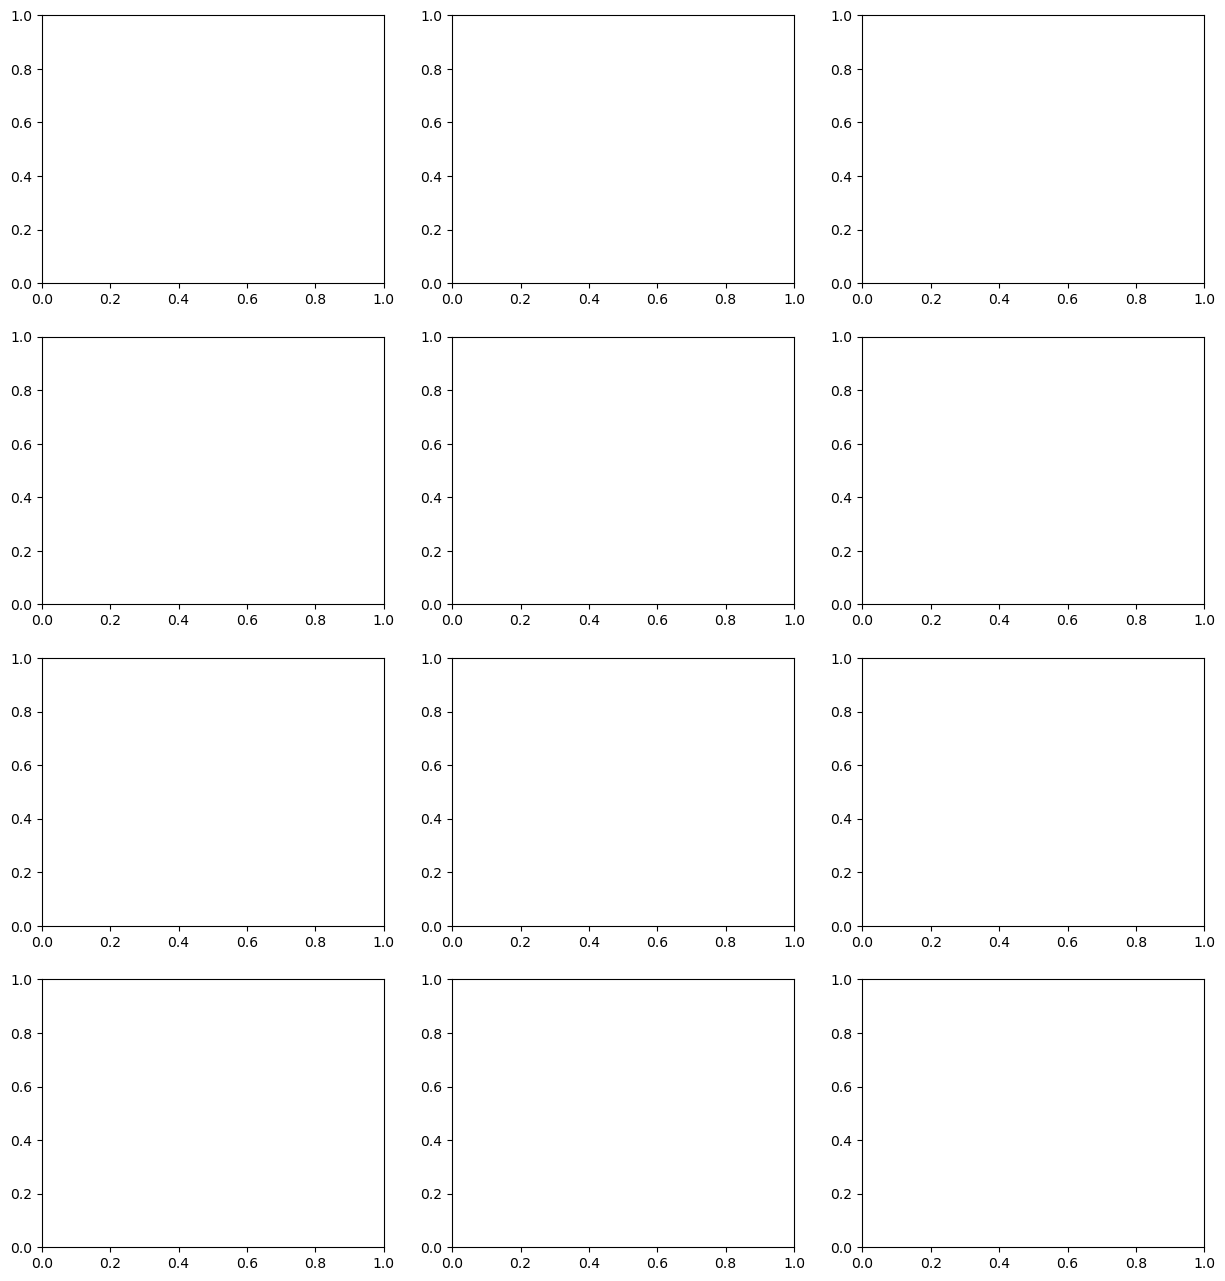

In [92]:
# fig. 1: parity plot (total energies)

fig, axes = plt.subplots(nrows=len(ADSORBATE_CALCS), ncols=len(MODELS),
                        figsize=(5*len(MODELS), 4*len(ADSORBATE_CALCS)))

for row, ads in enumerate(ADSORBATE_CALCS):
    for col, model in enumerate(MODELS):
        ax = axes[row][col]

axes = np.array(axes).flatten()  # E_DFT = E_MLIP

plt.show()